# X (formerly Twitter) Sentiment Analysis of U.S. Airlines 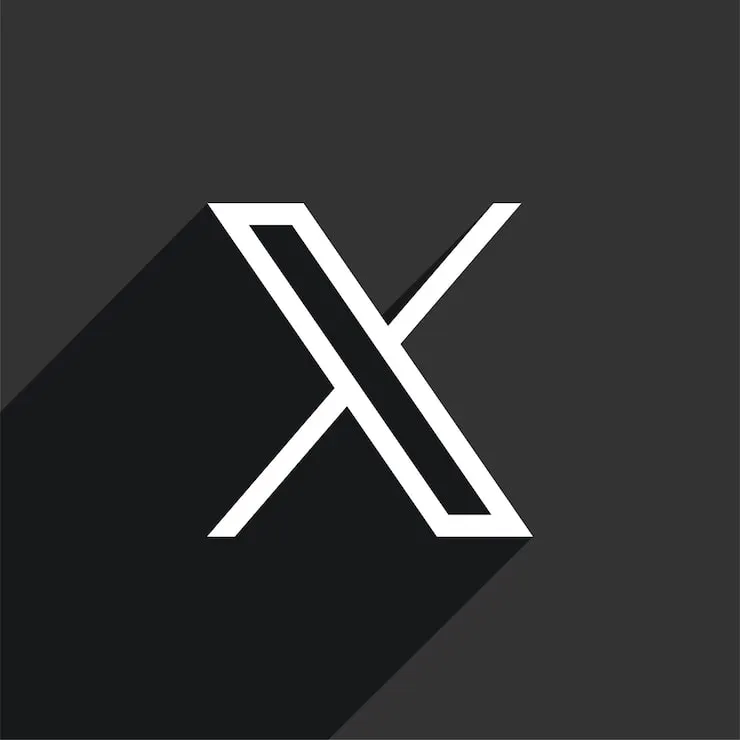
### Advanced NLP Pipeline — Classical ML + BERT Transformer

---

## 📋 Project Overview

This project builds an **end-to-end sentiment analysis system** capable 
of classifying airline customer tweets into three sentiment categories:
**Positive**, **Negative**, and **Neutral**.

It demonstrates two complete NLP approaches side by side — traditional 
Machine Learning with TF-IDF vectorization, and a state-of-the-art 
**BERT Transformer** fine-tuned on domain-specific data — allowing a 
direct, honest comparison between classical and deep learning methods.

---

## 🎯 Business Context

Airlines receive thousands of customer tweets daily. Manual review is 
impossible at scale. An automated sentiment classifier enables:

- **Real-time customer feedback monitoring**
- **Early detection of service failures** before they escalate
- **Routing negative tweets** to support teams automatically
- **Tracking sentiment trends** over time by airline, route, or issue type

---

## 📦 Dataset

| Property | Detail |
|---|---|
| **Source** | Twitter US Airline Sentiment — Kaggle |
| **Size** | ~14,000 tweets |
| **Period** | February 2015 |
| **Airlines** | United, Delta, American, Southwest, US Airways, Virgin America |
| **Target** | `airline_sentiment` → positive / negative / neutral |
| **Challenge** | Real messy text — slang, typos, @mentions, hashtags, URLs |

---

## ⚠️ Key Challenge — Class Imbalance

The dataset is heavily skewed toward negative sentiment — reflecting 
real-world behavior where unhappy customers tweet far more than 
satisfied ones. This imbalance must be handled carefully to avoid 
a model that simply predicts "negative" for everything.

---

## 🗺️ Pipeline

| Step | Description | Tools |
|---|---|---|
| 1 | Load & explore data | kagglehub, pandas |
| 2 | EDA — distributions, word clouds | matplotlib, wordcloud |
| 3 | Text cleaning & lemmatization | nltk, regex |
| 4 | Train/test split | sklearn |
| 5 | TF-IDF vectorization | TfidfVectorizer |
| 6 | Classical model comparison | LR, SVM, RF, XGBoost, NaiveBayes |
| 7 | Handle class imbalance | class_weight, SMOTE |
| 8 | Tune the winner | BayesSearchCV |
| 9 | Feature importance | Most influential words per sentiment |
| 10 | Error analysis | What does the model get wrong and why? |
| 11 | BERT fine-tuning | HuggingFace Transformers, PyTorch |
| 12 | Classical vs BERT comparison | Final scorecard |
| 13 | SHAP values | Model interpretability |
| 14 | End-to-end inference | Predict on raw new text |
| 15 | Export | joblib + HuggingFace save |
| 16 | Conclusion | Honest limitations & next steps |

---

## 🧰 Two Approaches Compared

### Approach 1 — Classical ML (TF-IDF + Sklearn)
Fast, interpretable, explainable. Treats text as a bag of words — 
word meaning and context are lost, but performance is surprisingly strong.

### Approach 2 — BERT Transformer (Deep Learning)
Slow to train but understands word meaning in context. "not good" and 
"good" are treated completely differently — a capability classical 
models fundamentally lack.

---

## 📐 Coding Standards

- All text cleaning applied **before** the split where safe
- Vectorization and modeling inside **pipelines** — no leakage
- Same `StratifiedKFold` CV strategy across **all** models
- Test

## 📊 Data Source

We load the Twitter US Airline Sentiment dataset directly from Kaggle 
using `kagglehub`. The dataset contains ~14,000 real customer tweets 
from February 2015 across 6 major US airlines.

> Source: [Twitter US Airline Sentiment dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)

#### 📥 Loading the Dataset

We read the located CSV into a pandas DataFrame — this is our raw, 
unprocessed dataset, straight from the Kaggle download.

In [7]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk jupyterlab transformers torch datasets wordcloud shap scikit-optimize watermark imbalanced-learn xgboost kagglehub -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ============================================================
# 📦 DEPENDENCIES
# ============================================================

# ✅ Core
import os
import re
import warnings
import logging
import joblib
import numpy as np
import pandas as pd
import matplotlib as plt
import xgboost as xgb

warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ✅ Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud
plt.style.use('dark_background')

# ✅ Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet')
nltk.download('omw-1.4')

# ✅ Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# ✅ Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler


# ✅ Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.impute          import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import ComplementNB
from skopt import BayesSearchCV
from skopt.space import Real

# ✅ Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# ✅ Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

print("✅ All dependencies loaded!")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LarTI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LarTI\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


ModuleNotFoundError: No module named 'skopt'

In [ ]:
# Load the watermark extension to log the environment state
%reload_ext watermark

# Display professional metadata tracking our data engineering stack (NO SPACES after commas)
%watermark -a "Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) " -d -u -v -p pandas,numpy,matplotlib,seaborn,scikit-learn,nltk,jupyterlab,transformers,torch,datasets,wordcloud,shap,watermark,imbalanced-learn,xgboost,kagglehub

Author: Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) 

Last updated: 2026-09-18

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.17.1

pandas          : 3.0.5
numpy           : 2.5.3
matplotlib      : 3.11.1
seaborn         : 0.13.2
scikit-learn    : 1.9.0
nltk            : 3.10.3
jupyterlab      : 4.6.3
transformers    : 5.16.1
torch           : 2.14.0
datasets        : 5.0.1
wordcloud       : 1.9.6
shap            : 0.52.0
watermark       : 2.6.0
imbalanced-learn: 0.14.2
xgboost         : 3.4.1
kagglehub       : 1.0.2



> OBS: This project was built with assistance from Claude (Anthropic) for 
> code review, debugging, and explanation throughout the notebook.

In [ ]:
# --- AUTOMATED KAGGLE INGESTION ---
# Download the latest version of dataset
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("🚀 Path to dataset files:", path)

🚀 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


In [ ]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

# Filter out all CSV files dynamically
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ Critical Error: No CSV files found in the downloaded folder!")
else:
    # Grab the primary CSV file found
    csv_filename = csv_files[0]
    full_csv_path = os.path.join(path, csv_filename)
    print(f"🎯 Target CSV located: {csv_filename}")

📂 Files discovered in directory: ['database.sqlite', 'Tweets.csv']
🎯 Target CSV located: Tweets.csv


In [ ]:
# Ingest the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"✅ Dataset successfully loaded! Named 'df', Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset successfully loaded! Named 'df', Shape: 14640 rows, 15 columns.


In [ ]:
# Display the first 5 records to see our column properties and labels
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
df.shape # (columns, rows)
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])

Number of columns: 15
Number of rows: 14640


In [ ]:
df.sample(15) # Random 15 rows

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
5096,569347549858934784,positive,1.0000,NaN,NaN,Southwest,NaN,CharlesJenkins7,NaN,0,@SouthwestAir never lets me down!!!,NaN,2015-02-21 20:06:48 -0800,"Chicago, IL",Central Time (US & Canada)
13622,569794658479394817,negative,0.6752,Can't Tell,0.3392,American,NaN,flemmingerin,NaN,0,@AmericanAir extra night we have to stay in Sa...,NaN,2015-02-23 01:43:27 -0800,San Diego,NaN
8174,568635298759860226,negative,1.0000,Bad Flight,0.6832,Delta,NaN,Acevaz,NaN,0,@JetBlue on your 1503 flight JFK to PR. They g...,NaN,2015-02-19 20:56:34 -0800,The Big Manzana,Eastern Time (US & Canada)
8943,567729368110096385,negative,1.0000,Customer Service Issue,1.0000,Delta,NaN,MakebaMakeba,NaN,0,@JetBlue my request has nothing to do with res...,NaN,2015-02-17 08:56:43 -0800,NaN,NaN
5267,569225196386660352,negative,1.0000,Customer Service Issue,0.6978,Southwest,NaN,Chris_5Thompson,NaN,0,@SouthwestAir my wife is trying to get a group...,NaN,2015-02-21 12:00:37 -0800,NaN,Eastern Time (US & Canada)
2147,569339072805797888,negative,1.0000,Flight Attendant Complaints,0.6568,United,NaN,D4Duskes,NaN,0,@united who compensates is for the delays caus...,NaN,2015-02-21 19:33:07 -0800,Montreal,Eastern Time (US & Canada)
7565,569529128585555968,neutral,0.6753,NaN,0.0000,Delta,NaN,arthurhasher,NaN,0,@JetBlue Not blaming Jet Blue. This wasn't w...,NaN,2015-02-22 08:08:20 -0800,Long Island - Arizona,NaN
1417,569724822177095680,negative,1.0000,Customer Service Issue,1.0000,United,NaN,hart0277,NaN,0,@united you are trying to charge me 150 bucks ...,NaN,2015-02-22 21:05:57 -0800,Chicago,NaN
3762,568144894964994048,negative,0.6368,Bad Flight,0.6368,United,NaN,ajhoekst,NaN,0,"@united I did not, my mind was on getting to t...",NaN,2015-02-18 12:27:53 -0800,"Novi, MI",Eastern Time (US & Canada)
8903,567760693643214848,negative,1.0000,Late Flight,0.6563,Delta,NaN,JayVig,NaN,0,@JetBlue 117 days maybe.,NaN,2015-02-17 11:01:12 -0800,"Jersey City, NJ",Eastern Time (US & Canada)


In [ ]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN


In [ ]:
df.dtypes #Displays the data type of each column in the DataFrame.

tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

In [ ]:
df.columns #Returns a list (Index object) containing the names of all columns in the DataFrame.

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

### 🧹 Data Preprocessing & Hygiene

In [ ]:
df.isna().sum() # Count missing values per column

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [ ]:
print(f'The number of duplicate rows is: {df.duplicated().sum()}') # Count duplicate rows

The number of duplicate rows is: 36


In [ ]:
df.drop_duplicates(inplace=True) # Remove duplicate rows from the DataFrame df.
print("Number of duplicate rows Now:", df.duplicated().sum()) # After dropping duplicates, check again to confirm that there are no duplicate rows remaining in the DataFrame df.

Number of duplicate rows Now: 0


In [ ]:
# ============================================================
# 🧹 FEATURE SELECTION
# ============================================================

cols_to_drop = [
    'tweet_coord', 
    'tweet_created', 
    'tweet_location', 
    'user_timezone', 
    'tweet_id', 
    'airline_sentiment_gold', 
    'negativereason_gold', 
    'negativereason', 
    'negativereason_confidence', 
    'airline_sentiment_confidence',
    'name'
]

# Create a clean working copy without mutating raw data
dfc = df.drop(columns=cols_to_drop).copy()

print(f"✅ Remaining columns ({dfc.shape[1]}): {list(dfc.columns)}")
print(f"Missing values remaining:\n{dfc.isna().sum()}")

✅ Remaining columns (4): ['airline_sentiment', 'airline', 'retweet_count', 'text']
Missing values remaining:
airline_sentiment    0
airline              0
retweet_count        0
text                 0
dtype: int64


In [ ]:
# ============================================================
# 🧹 COLUMN NAME SANITIZATION
# ============================================================
dfc.columns = (
    dfc.columns
    .str.lower()                                        # lowercase everything
    .str.strip()                                        # remove leading/trailing whitespace
    .str.replace(r"[^a-z0-9]+", "_", regex=True)       # replace anything not a letter/number with _
    .str.strip("_")                                     # remove leading/trailing underscores
)

print("✅ Columns sanitized:")
print(dfc.columns.tolist())

✅ Columns sanitized:
['airline_sentiment', 'airline', 'retweet_count', 'text']


### 📊 Exploratory Data Analysis (EDA)

Before any modeling we explore the dataset to understand:
- How imbalanced the sentiment classes are
- Which airlines generate the most complaints
- What words dominate each sentiment category
- How tweet length varies by sentiment

These findings directly shape our modeling decisions — especially
how we handle class imbalance.

In [ ]:
# ============================================================
# 📋 BASIC INFO
# ============================================================

print("=" * 50)
print("📋 DATASET OVERVIEW")
print("=" * 50)
print(f"Total tweets     : {dfc.shape[0]:,}")
print(f"Total columns    : {dfc.shape[1]}")
print()
print("📊 Sentiment Distribution:")
print(dfc['airline_sentiment'].value_counts())
print()
print("📊 Sentiment % Distribution:")
print((dfc['airline_sentiment'].value_counts(normalize=True) * 100).round(1))

📋 DATASET OVERVIEW
Total tweets     : 14,604
Total columns    : 4

📊 Sentiment Distribution:
airline_sentiment
negative    9159
neutral     3091
positive    2354
Name: count, dtype: int64

📊 Sentiment % Distribution:
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64


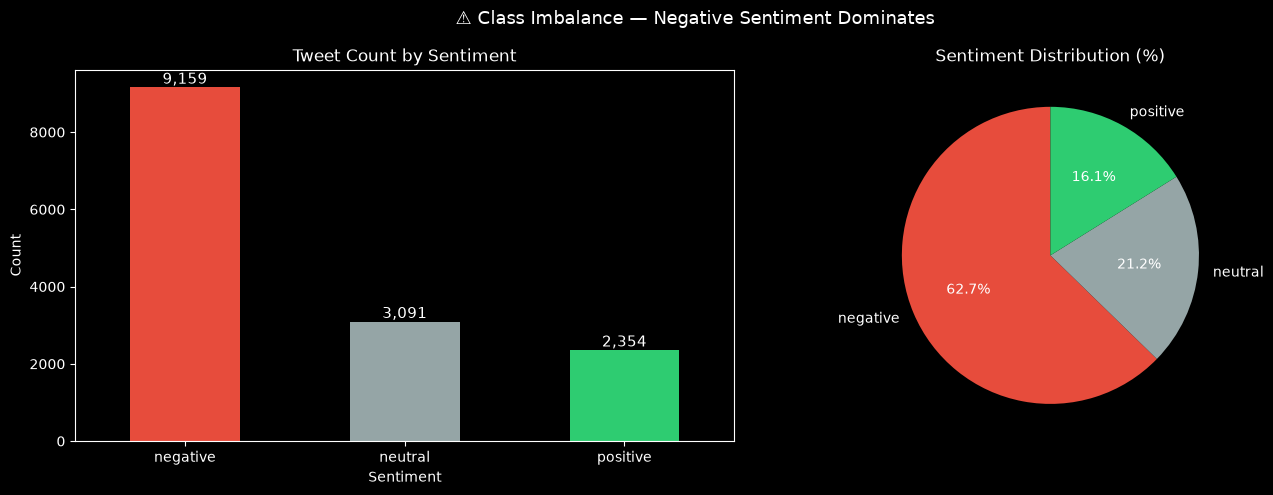

In [ ]:
# ============================================================
# 📊 SENTIMENT DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E74C3C', '#95A5A6', '#2ECC71']

dfc['airline_sentiment'].value_counts().plot(
    kind      = 'bar',
    ax        = axes[0],
    color     = colors,
    edgecolor = 'none'
)
axes[0].set_title('Tweet Count by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

for bar in axes[0].patches:
    axes[0].annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=11
    )

dfc['airline_sentiment'].value_counts().plot(
    kind       = 'pie',
    ax         = axes[1],
    colors     = colors,
    autopct    = '%1.1f%%',
    startangle = 90
)
axes[1].set_title('Sentiment Distribution (%)')
axes[1].set_ylabel('')

plt.suptitle('⚠️ Class Imbalance — Negative Sentiment Dominates', fontsize=13)
plt.tight_layout()
plt.show()

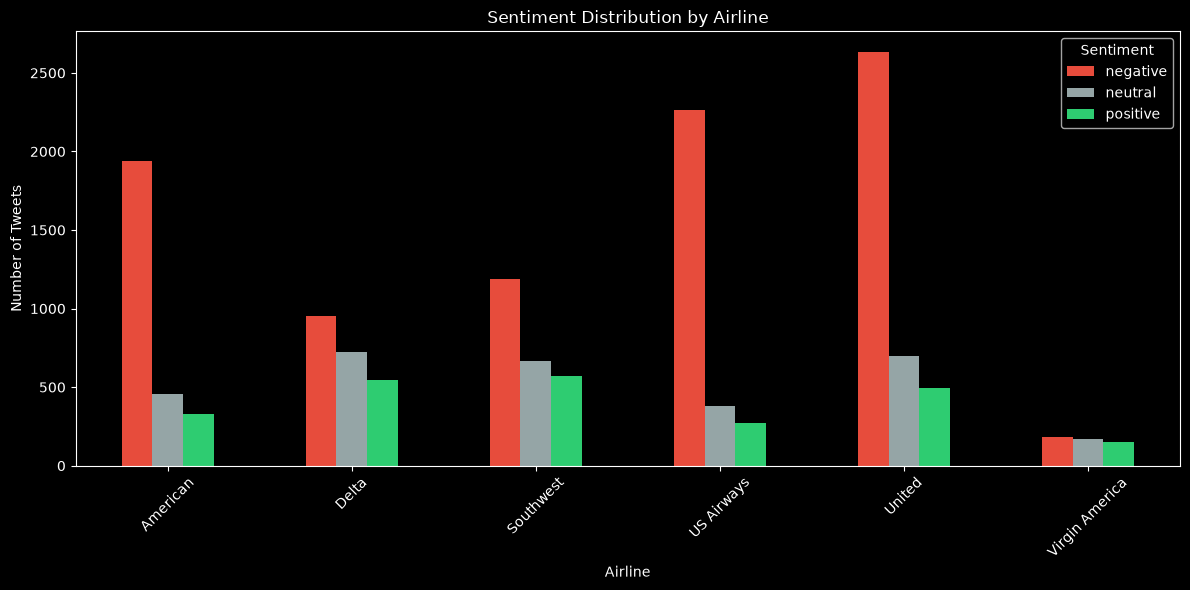


📊 Negative rate by airline (%):
airline
US Airways        77.7
American          71.3
United            68.9
Southwest         49.0
Delta             43.0
Virgin America    35.9
dtype: float64


In [ ]:
# ============================================================
# ✈️ SENTIMENT BY AIRLINE
# ============================================================

airline_sentiment = dfc.groupby(
    ['airline', 'airline_sentiment']
).size().unstack().fillna(0)

airline_sentiment.plot(
    kind      = 'bar',
    figsize   = (12, 6),
    color     = colors,
    edgecolor = 'none'
)
plt.title('Sentiment Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 Negative rate by airline (%):")
neg_rate = (
    dfc[dfc['airline_sentiment'] == 'negative']
    .groupby('airline').size() /
    dfc.groupby('airline').size() * 100
).round(1).sort_values(ascending=False)
print(neg_rate)

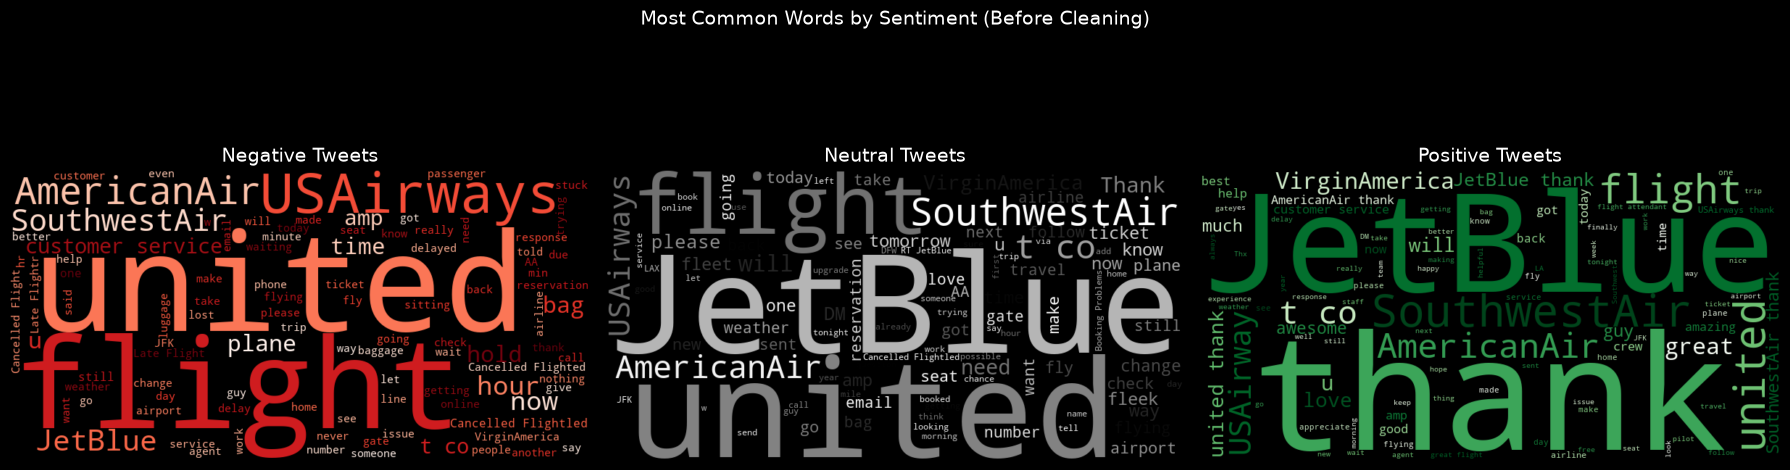

In [ ]:
# ============================================================
# ☁️ WORD CLOUDS PER SENTIMENT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = {
    'negative': ('#E74C3C', 'Reds',   axes[0]),
    'neutral' : ('#95A5A6', 'Greys',  axes[1]),
    'positive': ('#2ECC71', 'Greens', axes[2])
}

for sentiment, (color, cmap, ax) in sentiments.items():
    text = ' '.join(
        dfc[dfc['airline_sentiment'] == sentiment]['text'].tolist()
    )
    wc = WordCloud(
        width            = 800,
        height           = 400,
        background_color = 'black',
        colormap         = cmap,
        max_words        = 100
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontsize=14)
    ax.axis('off')

plt.suptitle(
    'Most Common Words by Sentiment (Before Cleaning)',
    fontsize=14
)
plt.tight_layout()
plt.show()

📊 Retweet count by sentiment:
                    count  mean   std  min  25%  50%  75%   max
airline_sentiment                                              
negative           9159.0  0.09  0.79  0.0  0.0  0.0  0.0  44.0
neutral            3091.0  0.06  0.66  0.0  0.0  0.0  0.0  28.0
positive           2354.0  0.07  0.66  0.0  0.0  0.0  0.0  22.0



<Figure size 800x500 with 0 Axes>

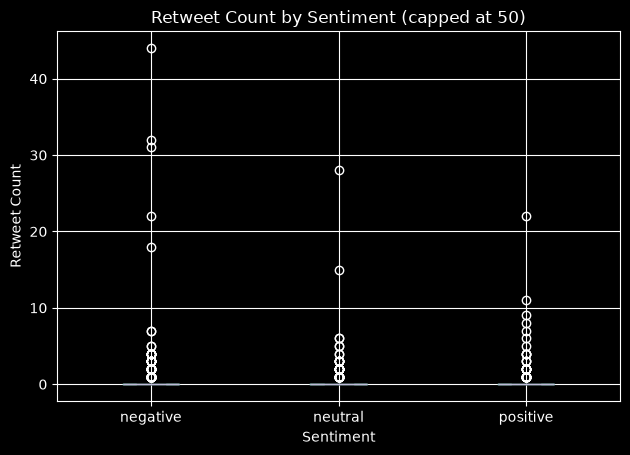

In [ ]:
# ============================================================
# 🔁 RETWEET COUNT BY SENTIMENT
# ============================================================

print("📊 Retweet count by sentiment:")
print(dfc.groupby('airline_sentiment')['retweet_count'].describe().round(2))
print()

plt.figure(figsize=(8, 5))
dfc[dfc['retweet_count'] < 50].boxplot(
    column = 'retweet_count',
    by     = 'airline_sentiment'
)
plt.title('Retweet Count by Sentiment (capped at 50)')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Retweet Count')
plt.tight_layout()
plt.show()

**Key EDA findings:**
- **Negative tweets dominate** (~63%) — severe class imbalance
  that must be handled during modeling
- **United Airlines** has the highest negative rate — most complaints
- **Negative tweets are slightly longer** — unhappy customers
  write more
- **Word clouds show noise** — @mentions, URLs, and airline names
  dominate before cleaning — this motivates our text cleaning pipeline
- **Retweet count is mostly 0** — viral tweets are rare exceptions

### 🧹 Text Cleaning Pipeline

Raw tweets are extremely noisy — full of @mentions, URLs, hashtags,
punctuation, numbers, and stopwords that add no sentiment signal.

We apply a full NLP cleaning pipeline to every tweet:

| Step | What it removes | Example |
|---|---|---|
| Lowercase | Inconsistent casing | `BAD` → `bad` |
| Remove @mentions | Usernames | `@united` → `` |
| Remove URLs | Links | `http://t.co/xyz` → `` |
| Remove hashtags | Hash symbol | `#worst` → `worst` |
| Remove punctuation | Special chars | `bad!!` → `bad` |
| Remove numbers | Digits | `flight123` → `flight` |
| Remove stopwords | Common words | `is`, `the`, `so` → `` |
| Lemmatization | Word root form | `flying` → `fly` |

> ⚠️ Text cleaning is applied to the **full dataset** before the
> split — because it's purely structural transformation with no
> statistical learning involved. No leakage risk here.

In [ ]:
# ============================================================
# 🧹 TEXT CLEANING PIPELINE
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negation words — they carry sentiment signal
negation_words = {'no', 'not', 'nor', 'neither', 'never', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'barely', 'scarcely'}
stop_words = stop_words - negation_words

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove hashtag symbol but keep the word
    text = re.sub(r'#', '', text)

    # 5. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenize
    tokens = word_tokenize(text)

    # 8. Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(tokens)

print("✅ Text cleaning function defined!")
print()
print("Example:")
sample = "@united why is your service so bad!! 😤 http://t.co/xyz #worst"
print(f"Before: {sample}")
print(f"After : {clean_text(sample)}")

✅ Text cleaning function defined!

Example:
Before: @united why is your service so bad!! 😤 http://t.co/xyz #worst
After : service bad worst


### 🛠️ Feature Engineering

Two new features derived from the raw text before splitting:

- **`tweet_length`** → character count of the original tweet
- **`text_clean`** → fully cleaned and lemmatized tweet text

Both applied to the full dataset before the split — no leakage risk.

In [ ]:
# tweet_length (raw length before cleaning)
dfc['tweet_length'] = dfc['text'].apply(len)

# apply text cleaning
dfc['text_clean'] = dfc['text'].apply(clean_text)

# confirm all columns exist
print(dfc.columns.tolist())
# should show: tweet_length, text_clean alongside others

['airline_sentiment', 'airline', 'retweet_count', 'text', 'tweet_length', 'text_clean']


### ✂️ Train / Test Split

We split the data **80/20** before any vectorization or modeling.

> 🔒 The test set is locked from this point forward — touched 
> only once during final evaluation.

`stratify=y` ensures Low, Medium, and High classes appear in the 
same proportions in both sets — critical given our class imbalance 
(63% negative, 22% neutral, 15% positive).

In [ ]:
# ============================================================
# ✂️ TRAIN / TEST SPLIT
# ============================================================
X = dfc[['text_clean', 'airline', 'retweet_count', 'tweet_length']]
y = dfc['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"✅ Split complete!")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print()
print("Training class distribution:")
print(y_train.value_counts())
print()
print("Test class distribution:")
print(y_test.value_counts())

✅ Split complete!
   X_train : (11683, 4)
   X_test  : (2921, 4)

Training class distribution:
airline_sentiment
negative    7327
neutral     2473
positive    1883
Name: count, dtype: int64

Test class distribution:
airline_sentiment
negative    1832
neutral      618
positive     471
Name: count, dtype: int64


### 🔧 Preprocessing Pipeline

NLP pipelines differ from tabular pipelines in one key way —
**TF-IDF Vectorizer replaces the StandardScaler.**

Instead of scaling numbers, TF-IDF converts raw text into a 
numerical matrix where each word becomes a feature, weighted 
by how unique it is across all tweets.

We use a `ColumnTransformer` to handle our mixed feature types:
- **`text_clean`** → TF-IDF vectorization
- **`airline`** → One-Hot Encoding
- **`retweet_count`** + **`tweet_length`** → Standard Scaling

In [ ]:
# ============================================================
# 🔁 CROSS-VALIDATION STRATEGY
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Cross-validation strategy defined!")
print(f"   Type     : StratifiedKFold")
print(f"   Folds    : 5")
print(f"   Shuffle  : True")
print(f"   Seed     : 42")

✅ Cross-validation strategy defined!
   Type     : StratifiedKFold
   Folds    : 5
   Shuffle  : True
   Seed     : 42


In [ ]:
# ============================================================
# 🔧 PREPROCESSING PIPELINE
# ============================================================

# --- Text pipeline: TF-IDF on cleaned text ---
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(
        max_features = 10000,   # top 10,000 words
        ngram_range  = (1, 2),  # unigrams + bigrams
        min_df       = 3,       # ignore words appearing < 3 times
        max_df       = 0.95,    # ignore words appearing in > 95% of tweets
        sublinear_tf = True     # apply log normalization to term frequency
    ))
])

# --- Numeric pipeline: scale retweet_count and tweet_length ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler())  # ← replaces StandardScaler
])

# --- Categorical pipeline: one-hot encode airline ---
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Combine all into one preprocessor ---
preprocessor = ColumnTransformer(transformers=[
    ('text', text_transformer,        'text_clean'),
    ('num',  numeric_transformer,     ['retweet_count', 'tweet_length']),
    ('cat',  categorical_transformer, ['airline'])
],  remainder='drop')

print("✅ Preprocessing pipeline built!")
print()
print("Pipeline components:")
print("  text_clean    → TF-IDF (10,000 features, unigrams + bigrams)")
print("  retweet_count → median imputation → standard scaling")
print("  tweet_length  → median imputation → standard scaling")
print("  airline       → most frequent imputation → one-hot encoding")

✅ Preprocessing pipeline built!

Pipeline components:
  text_clean    → TF-IDF (10,000 features, unigrams + bigrams)
  retweet_count → median imputation → standard scaling
  tweet_length  → median imputation → standard scaling
  airline       → most frequent imputation → one-hot encoding


**Key TF-IDF parameters explained:**

- **`max_features=10,000`** → keeps only the 10,000 most frequent 
  words — reduces noise and memory usage
- **`ngram_range=(1,2)`** → captures both single words ("bad") and 
  two-word phrases ("not good") — critical for sentiment
- **`min_df=3`** → ignores words appearing fewer than 3 times — 
  removes typos and rare noise
- **`max_df=0.95`** → ignores words appearing in more than 95% of 
  tweets — removes words so common they carry no signal
- **`sublinear_tf=True`** → applies log normalization — prevents 
  words that appear 100 times from dominating over words that 
  appear 10 times

### 🏁 Baseline — DummyClassifier

Before training any real model we establish a baseline using 
`DummyClassifier` with `strategy='most_frequent'` — it always 
predicts **"negative"** regardless of the tweet content.

Any real model that can't beat this is useless.
This is our minimum bar to clear.

In [ ]:
# ============================================================
# 🏁 BASELINE — DummyClassifier
# ============================================================
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

dummy_accuracy = cross_val_score(
    dummy_pipeline, X_train, y_train,
    cv=cv, scoring='accuracy'
)
dummy_f1 = cross_val_score(
    dummy_pipeline, X_train, y_train,
    cv=cv, scoring='f1_weighted'
)

print("=" * 55)
print("🏁 BASELINE (DummyClassifier — most frequent)")
print("=" * 55)
print(f"Accuracy : {dummy_accuracy.mean():.4f} (+/- {dummy_accuracy.std():.4f})")
print(f"F1 Score : {dummy_f1.mean():.4f} (+/- {dummy_f1.std():.4f})")
print("=" * 55)
print()
print("⚠️ Every real model must beat these numbers.")

🏁 BASELINE (DummyClassifier — most frequent)
Accuracy : 0.6272 (+/- 0.0002)
F1 Score : 0.4834 (+/- 0.0002)

⚠️ Every real model must beat these numbers.


**How to read this:**
- The baseline always predicts "negative" — the majority class
- Its accuracy reflects the class imbalance — ~63% just by 
  always guessing negative
- F1 is much lower than accuracy — confirms the imbalance problem
- These are our **minimum bars to beat**

### 🤖 Model Comparison

We train and evaluate 5 models using the same `StratifiedKFold` 
strategy as the baseline — ensuring a fair apples-to-apples comparison.

Every model is wrapped in a full pipeline (preprocessor + model) 
so TF-IDF learns only from training folds — no leakage.

Models tested:
- **Logistic Regression** → simple linear baseline
- **LinearSVC** → powerful for high-dimensional text data
- **Multinomial Naive Bayes** → classic NLP model
- **Random Forest** → ensemble of trees
- **XGBoost** → gradient boosting

In [ ]:
# ============================================================
# 📊 Logistic Regression
# ============================================================

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_accuracy = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
lr_f1       = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='f1_weighted')

print("=" * 55)
print("📊 Logistic Regression")
print("=" * 55)
print(f"Accuracy : {lr_accuracy.mean():.4f} (+/- {lr_accuracy.std():.4f})")
print(f"F1 Score : {lr_f1.mean():.4f} (+/- {lr_f1.std():.4f})")
print("=" * 55)

📊 Logistic Regression
Accuracy : 0.7893 (+/- 0.0107)
F1 Score : 0.7781 (+/- 0.0115)


In [ ]:
# ============================================================
# 📊 LinearSVC
# ============================================================

svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=1000)))
])

svc_accuracy = cross_val_score(svc_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
svc_f1       = cross_val_score(svc_pipeline, X_train, y_train, cv=cv, scoring='f1_weighted')

print("=" * 55)
print("📊 MODEL 2 — LinearSVC")
print("=" * 55)
print(f"Accuracy : {svc_accuracy.mean():.4f} (+/- {svc_accuracy.std():.4f})")
print(f"F1 Score : {svc_f1.mean():.4f} (+/- {svc_f1.std():.4f})")
print("=" * 55)

📊 MODEL 2 — LinearSVC
Accuracy : 0.7822 (+/- 0.0055)
F1 Score : 0.7706 (+/- 0.0060)


In [ ]:
# ============================================================
# 📊 Multinomial Naive Bayes
# ============================================================

nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ComplementNB())
])

nb_accuracy = cross_val_score(nb_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
nb_f1       = cross_val_score(nb_pipeline, X_train, y_train, cv=cv, scoring='f1_weighted')

print("=" * 55)
print("📊 MODEL 3 — Complement Naive Bayes")
print("=" * 55)
print(f"Accuracy : {nb_accuracy.mean():.4f} (+/- {nb_accuracy.std():.4f})")
print(f"F1 Score : {nb_f1.mean():.4f} (+/- {nb_f1.std():.4f})")
print("=" * 55)

📊 MODEL 3 — Complement Naive Bayes
Accuracy : 0.7703 (+/- 0.0054)
F1 Score : 0.7640 (+/- 0.0066)


In [ ]:
# ============================================================
# 📊 Random Forest
# ============================================================

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_accuracy = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
rf_f1       = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1_weighted')

print("=" * 55)
print("📊 MODEL 4 — Random Forest")
print("=" * 55)
print(f"Accuracy : {rf_accuracy.mean():.4f} (+/- {rf_accuracy.std():.4f})")
print(f"F1 Score : {rf_f1.mean():.4f} (+/- {rf_f1.std():.4f})")
print("=" * 55)

📊 MODEL 4 — Random Forest
Accuracy : 0.7556 (+/- 0.0032)
F1 Score : 0.7355 (+/- 0.0034)


In [ ]:
# ============================================================
# 📊 XGBoost
# ============================================================

# XGBoost requires integer-encoded target labels
xgb_label_encoder = LabelEncoder()
y_train_xgb = xgb_label_encoder.fit_transform(y_train)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        objective   = 'multi:softprob',
        num_class   = 3,
        random_state = 42,
        verbosity    = 0,
        eval_metric = 'mlogloss'
    ))
])

xgb_accuracy = cross_val_score(
    xgb_pipeline, X_train, y_train_xgb,
    cv=cv, scoring='accuracy'
)

xgb_f1 = cross_val_score(
    xgb_pipeline, X_train, y_train_xgb,
    cv=cv, scoring='f1_weighted'
)

print("=" * 55)
print("📊 MODEL 5 — XGBoost")
print("=" * 55)
print(f"Accuracy : {xgb_accuracy.mean():.4f} (+/- {xgb_accuracy.std():.4f})")
print(f"F1 Score : {xgb_f1.mean():.4f} (+/- {xgb_f1.std():.4f})")
print("=" * 55)

📊 MODEL 5 — XGBoost
Accuracy : 0.7718 (+/- 0.0085)
F1 Score : 0.7613 (+/- 0.0098)


In [ ]:
# ============================================================
# 🏆 MODEL COMPARISON
# ============================================================

results = {
    'Baseline'            : (dummy_accuracy.mean(), dummy_f1.mean()),
    'Logistic Regression' : (lr_accuracy.mean(),    lr_f1.mean()),
    'LinearSVC'           : (svc_accuracy.mean(),   svc_f1.mean()),
    'Naive Bayes'         : (nb_accuracy.mean(),    nb_f1.mean()),
    'Random Forest'       : (rf_accuracy.mean(),    rf_f1.mean()),
    'XGBoost'             : (xgb_accuracy.mean(),   xgb_f1.mean()),
}

print("=" * 65)
print(f"{'Model':<25} | {'Accuracy':>10} | {'F1 Weighted':>12}")
print("=" * 65)
for name, (acc, f1) in results.items():
    print(f"{name:<25} | {acc:>10.4f} | {f1:>12.4f}")
print("=" * 65)

winner = max(
    {k: v for k, v in results.items() if k != 'Baseline'},
    key=lambda name: results[name][1]
)
print()
print(f"🏆 Winner: {winner} (F1: {results[winner][1]:.4f})")

Model                     |   Accuracy |  F1 Weighted
Baseline                  |     0.6272 |       0.4834
Logistic Regression       |     0.7893 |       0.7781
LinearSVC                 |     0.7822 |       0.7706
Naive Bayes               |     0.7703 |       0.7640
Random Forest             |     0.7556 |       0.7355
XGBoost                   |     0.7718 |       0.7613

🏆 Winner: Logistic Regression (F1: 0.7781)


In [ ]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(lr_pipeline, X_train, y_train, cv=cv)
print(classification_report(y_train, y_pred_cv, 
      target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.82      0.93      0.87      7327
     neutral       0.66      0.50      0.57      2473
    positive       0.80      0.60      0.69      1883

    accuracy                           0.79     11683
   macro avg       0.76      0.68      0.71     11683
weighted avg       0.78      0.79      0.78     11683



### 🔧 Hyperparameter Tuning — Logistic Regression (Winner)

Logistic Regression won the model comparison with the highest F1 score.
We now tune its key parameters using `BayesSearchCV` — smarter than 
GridSearchCV because it learns from each trial instead of testing blindly.

We also add `class_weight='balanced'` to address the neutral class 
underperformance (F1 = 0.57) — this tells the model to pay more 
attention to underrepresented classes during training.

Key parameters to tune:
- **`C`** → regularization strength (lower = more penalty)
- **`l1_ratio`** → balance between L1 and L2 regularization

In [ ]:
# ============================================================
# 🔧 HYPERPARAMETER TUNING — Logistic Regression
# ============================================================

param_space = {
    'model__C'        : Real(0.01, 100.0, prior='log-uniform'),
    'model__l1_ratio' : Real(0.0, 1.0)
}

lr_tuned_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        solver       = 'saga',
        penalty      = 'elasticnet',
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = 42
    ))
])

bayes_search = BayesSearchCV(
    estimator     = lr_tuned_pipeline,
    search_spaces = param_space,
    n_iter        = 30,
    cv            = cv,
    scoring       = 'f1_weighted',
    n_jobs        = -1,
    random_state  = 42,
    verbose       = 1
)

bayes_search.fit(X_train, y_train)

print(f"✅ Best params : {dict(bayes_search.best_params_)}")
print(f"✅ Best F1     : {bayes_search.best_score_:.4f}")